In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [103]:
df = pd.read_csv("data/processed/cleaned_atm_transactions.csv")
df.head()

,atmId,atmName,atmCity,atmAddress,totalBalance,numberIncomeTransaction,numberOutcomeTransaction,totalIncome,totalOutcome,totalNumberTransaction,day,transactionTime
0,atm350000,ali̇ağa bağli şb,izmir,aliağa petkim tesisleri,40000,0,0,0,0,0,wednesday,2020-01-01 0:00:00
1,atm350000,ali̇ağa bağli şb,izmir,aliağa petkim tesisleri,39850,9,18,485,1120,27,wednesday,2020-01-01 2:00:00
2,atm350000,ali̇ağa bağli şb,izmir,aliağa petkim tesisleri,39985,8,10,420,875,18,wednesday,2020-01-01 4:00:00
3,atm350000,ali̇ağa bağli şb,izmir,aliağa petkim tesisleri,38545,5,9,140,490,14,wednesday,2020-01-01 6:00:00
4,atm350000,ali̇ağa bağli şb,izmir,aliağa petkim tesisleri,39260,79,70,5220,4185,149,wednesday,2020-01-01 8:00:00


### Check Missing values

In [104]:
df.isnull().sum()

atmId                       0
atmName                     0
atmCity                     0
atmAddress                  0
totalBalance                0
numberIncomeTransaction     0
numberOutcomeTransaction    0
totalIncome                 0
totalOutcome                0
totalNumberTransaction      0
day                         0
transactionTime             0
dtype: int64

### Check Duplicates

In [105]:
print(df.duplicated().sum())

0


### Check data type

In [106]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29736 entries, 0 to 29735
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   atmId                     29736 non-null  str  
 1   atmName                   29736 non-null  str  
 2   atmCity                   29736 non-null  str  
 3   atmAddress                29736 non-null  str  
 4   totalBalance              29736 non-null  int64
 5   numberIncomeTransaction   29736 non-null  int64
 6   numberOutcomeTransaction  29736 non-null  int64
 7   totalIncome               29736 non-null  int64
 8   totalOutcome              29736 non-null  int64
 9   totalNumberTransaction    29736 non-null  int64
 10  day                       29736 non-null  str  
 11  transactionTime           29736 non-null  str  
dtypes: int64(6), str(6)
memory usage: 2.7 MB


### Check the number of unique values of each column

In [107]:
df.nunique()

atmId                        354
atmName                      354
atmCity                        1
atmAddress                   297
totalBalance                8774
numberIncomeTransaction       92
numberOutcomeTransaction      72
totalIncome                 1549
totalOutcome                1533
totalNumberTransaction       162
day                            7
transactionTime              168
dtype: int64

### Check statistics of data set

In [108]:
df.describe()

,totalBalance,numberIncomeTransaction,numberOutcomeTransaction,totalIncome,totalOutcome,totalNumberTransaction
count,29736.000000,29736.000000,29736.000000,29736.000000,29736.000000,29736.000000
mean,24916.803538,48.199388,55.116223,3091.955374,3535.519404,103.315611
std,12151.082105,31.314672,33.370831,2063.773253,2201.373245,61.060807
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15050.000000,16.000000,16.000000,1015.000000,1015.000000,27.000000
50%,25840.000000,50.000000,64.000000,3145.000000,4075.000000,125.000000
75%,35360.000000,76.000000,84.000000,4840.000000,5315.000000,153.000000
max,57050.000000,100.000000,100.000000,8440.000000,9710.000000,200.000000


### Check number of Numerical and Categorical features

In [109]:
numerical_features = [feature for feature in df.columns if df[feature].dtype != "str"]
categorical_features = [feature for feature in df.columns if df[feature].dtype == "str"]
print("Numerical_features are : -")
for idx,feature in enumerate(numerical_features):
    print(idx + 1, feature)

print("\nCategorical_features are : -")
for idx,feature in enumerate(categorical_features):
    print(idx + 1, feature)

Numerical_features are : -
1 totalBalance
2 numberIncomeTransaction
3 numberOutcomeTransaction
4 totalIncome
5 totalOutcome
6 totalNumberTransaction

Categorical_features are : -
1 atmId
2 atmName
3 atmCity
4 atmAddress
5 day
6 transactionTime


### Numerical distributions and correlations

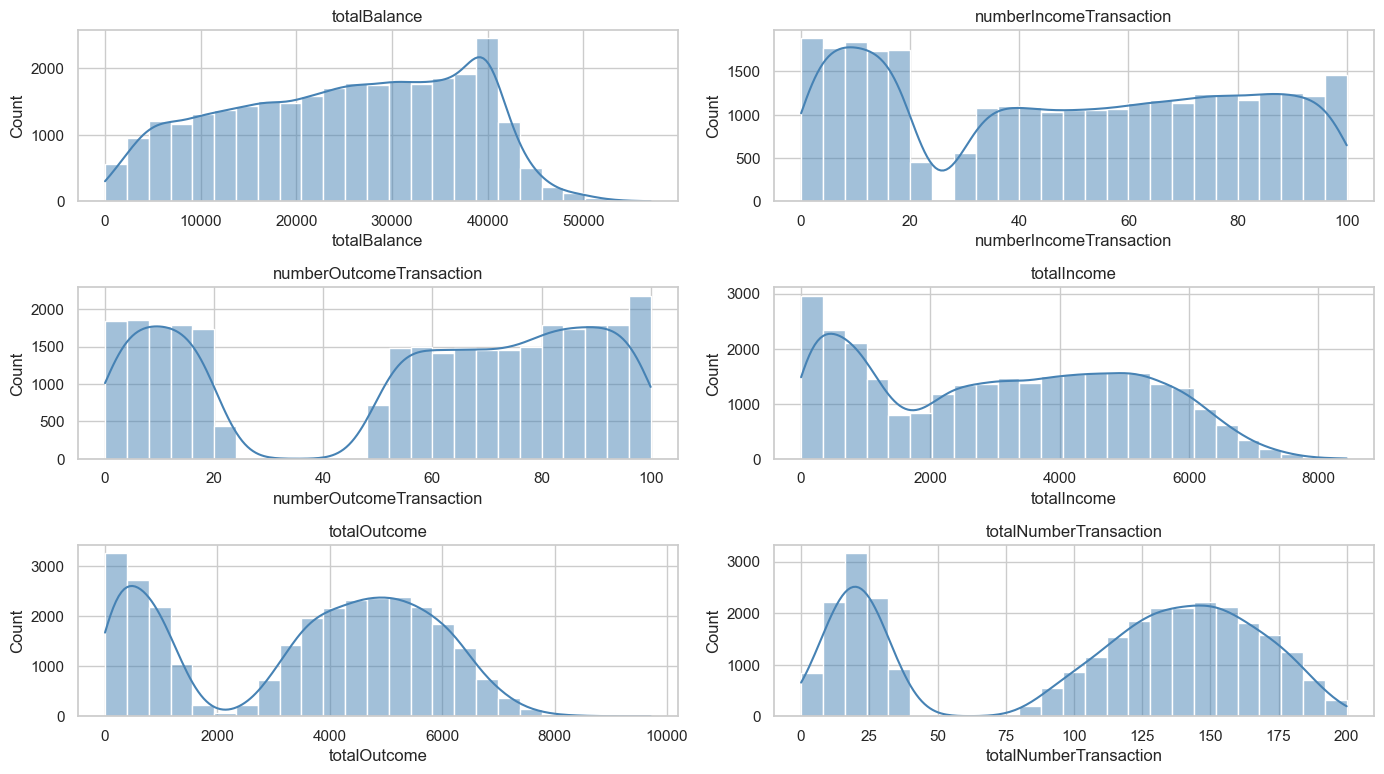

In [110]:
plt.figure(figsize=(14, 10))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(4, 2, i)
    sns.histplot(df[feature], kde=True, bins=25, color="steelblue")
    plt.title(feature)
    plt.tight_layout()

plt.show()

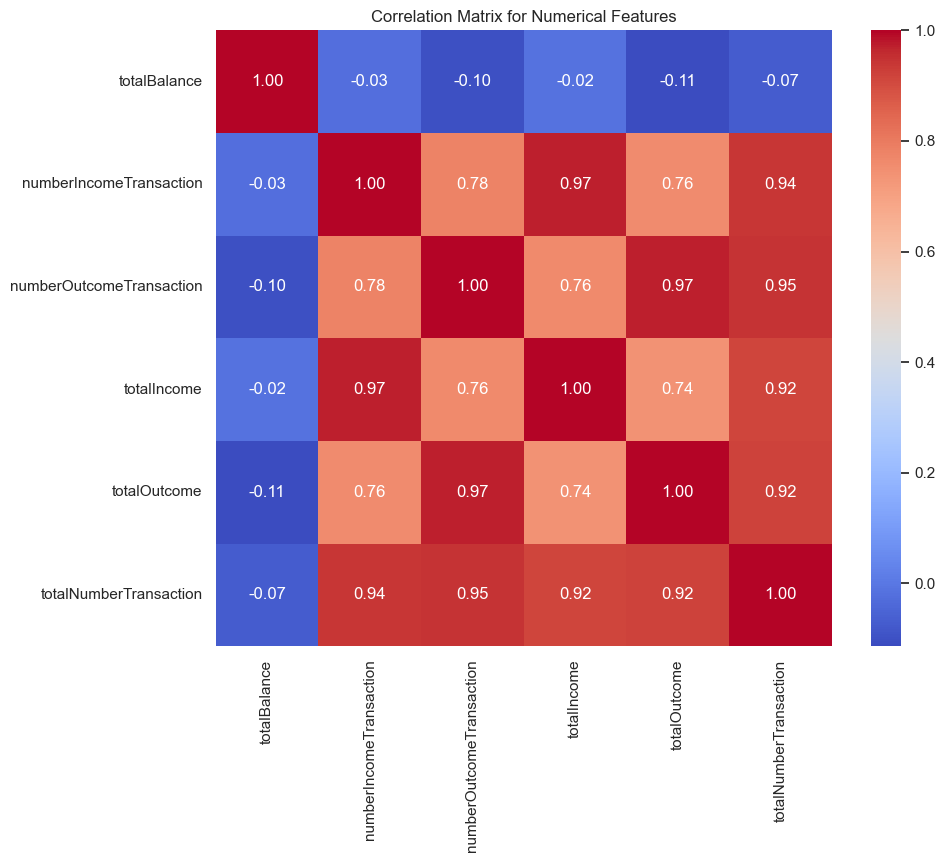

In [111]:
plt.figure(figsize=(10, 8))
correlation = df[numerical_features].corr()
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix for Numerical Features")
plt.show()

### Categorical distributions and high-level patterns

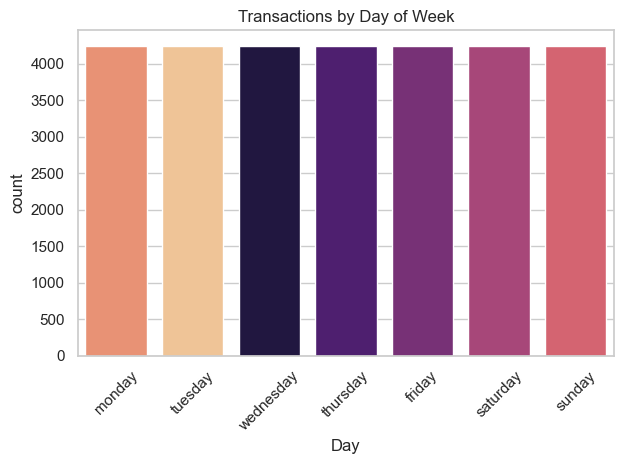

In [112]:
sns.countplot(data=df, x="day", order=["monday", "tuesday", "wednesday", "thursday", "friday", "saturday", "sunday"], hue='day',palette="magma")
plt.title("Transactions by Day of Week")
plt.xlabel("Day")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

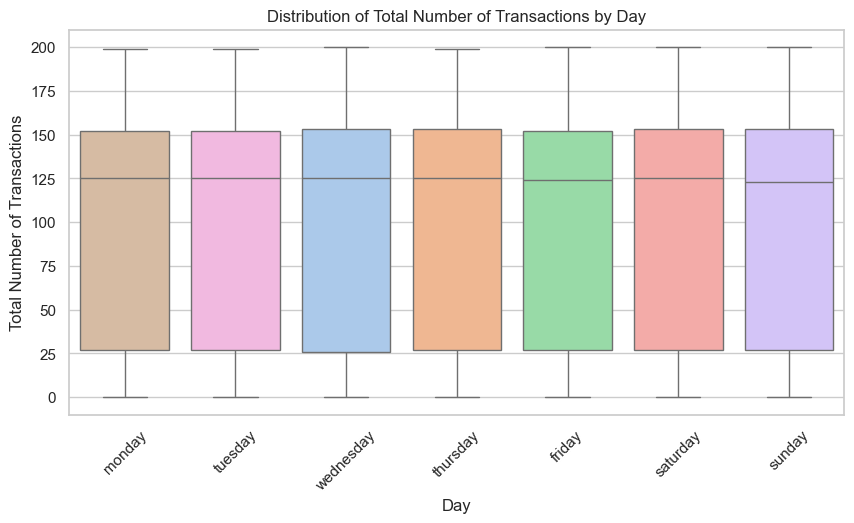

In [113]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="day", y="totalNumberTransaction", order=["monday", "tuesday", "wednesday", "thursday", "friday", "saturday", "sunday"], hue="day",palette="pastel")
plt.title("Distribution of Total Number of Transactions by Day")
plt.xlabel("Day")
plt.ylabel("Total Number of Transactions")
plt.xticks(rotation=45)
plt.show()

### Top ATMs by amount and transaction counts

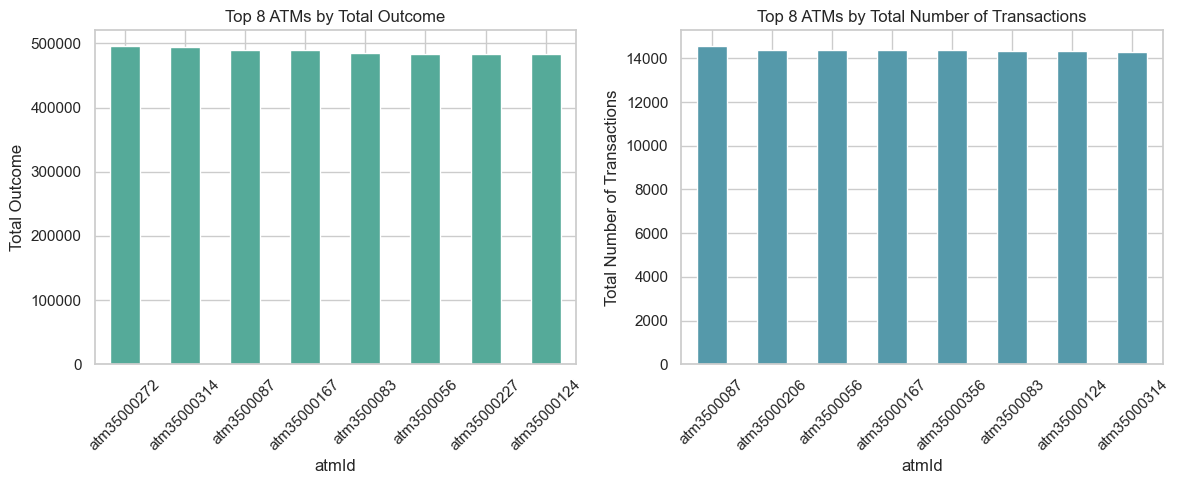

In [114]:
top_outcome = df.groupby("atmId")["totalOutcome"].sum().sort_values(ascending=False).head(8)
top_transactions = df.groupby("atmId")["totalNumberTransaction"].sum().sort_values(ascending=False).head(8)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
top_outcome.plot(kind="bar", color="#5A9")
plt.title("Top 8 ATMs by Total Outcome")
plt.ylabel("Total Outcome")
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
top_transactions.plot(kind="bar", color="#59A")
plt.title("Top 8 ATMs by Total Number of Transactions")
plt.ylabel("Total Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
